# SIREN Testing

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import gc

import sys
from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KDV

In [21]:
INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 8, 
    n_neurons_per_layer      = 48, 
    nl_outer                 = False,
    omega                    = 30,
    seed                     = 72, 
    verbose                  = True,
)

TRAIN_PARAMS = dict(
    adam_epochs              = 10000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,
    n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
    n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100, 
    lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
    adaptive_sampling        = False,   
    logging                  = True, #new parameter, stops loss logging bottleneck for quick training (no loss history)
    verbose                  = True,
)

TRAIN_WEIGHTS = dict( #seperated out from the train params
    w_ic                     = 5.0,    
    w_bc                     = 2.0,    
    w_pde                    = 15.0,
    w_momentum               = 1.0,
    w_energy                 = 0.1,
)

model = KDV(INIT_PARAMS)
training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)

Using device: cuda
Weighted losses [start]: IC=1.664e-01 | BC=3.317e-02 | PDE=2.741e+07
Starting Adam optimization...
[gpu mem] train start               alloc  2343.7 MB  reserved  2634.0 MB  peak  2343.7 MB
Adam - Epoch 0/10000, Total Loss: 2.740806e+07
Adam - Epoch 100/10000, Total Loss: 1.545723e+02
Adam - Epoch 200/10000, Total Loss: 6.022290e+01
Adam - Epoch 300/10000, Total Loss: 3.382524e+01
Adam - Epoch 400/10000, Total Loss: 2.194930e+01
Adam - Epoch 500/10000, Total Loss: 1.547936e+01
Adam - Epoch 600/10000, Total Loss: 1.153784e+01
Adam - Epoch 700/10000, Total Loss: 8.948826e+00
Adam - Epoch 800/10000, Total Loss: 7.154002e+00
Adam - Epoch 900/10000, Total Loss: 5.857600e+00
Adam - Epoch 1000/10000, Total Loss: 4.889875e+00
Adam - Epoch 1100/10000, Total Loss: 4.147634e+00
Adam - Epoch 1200/10000, Total Loss: 3.565412e+00
Adam - Epoch 1300/10000, Total Loss: 3.099796e+00
Adam - Epoch 1400/10000, Total Loss: 2.721104e+00
Adam - Epoch 1500/10000, Total Loss: 2.408458e+00
Ada

In [17]:
torch.cuda.empty_cache()

In [19]:
#del model
#del training_stats
torch.cuda.memory_allocated()

18971648

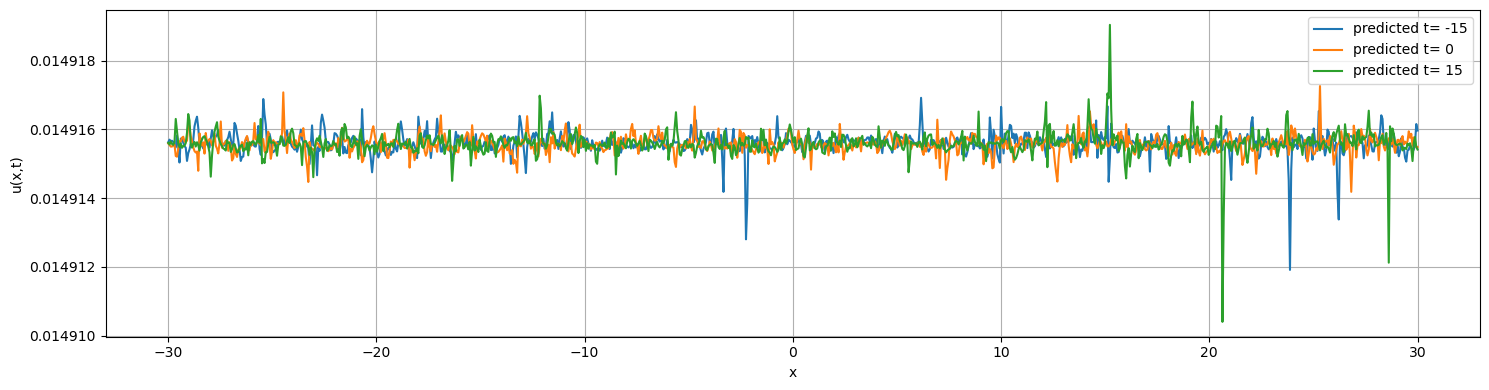

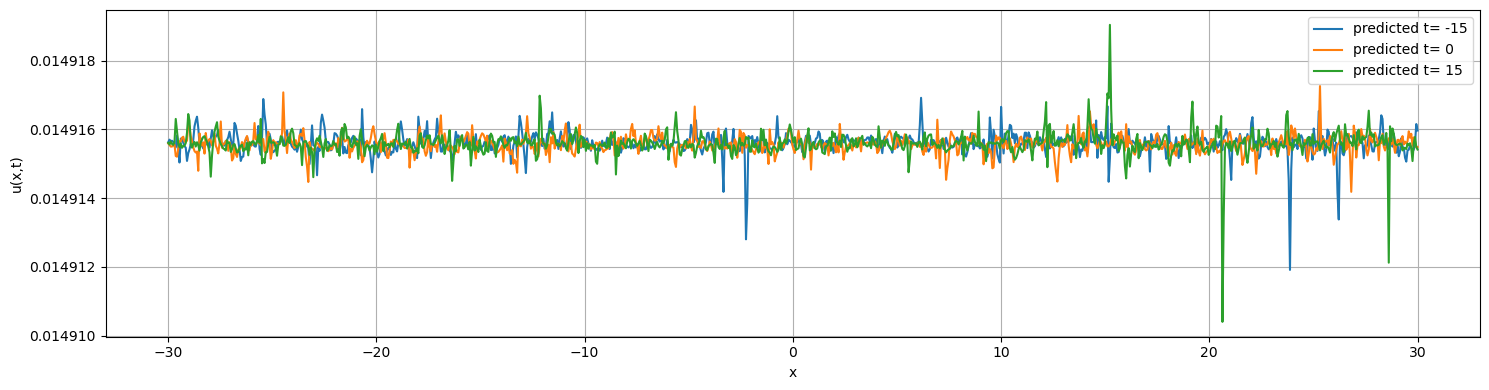

In [23]:
model.plot_profiles(t_values=[-15, 0, 15])